# Simple AE

## 1. Preparing Data

In [2]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input , Dense
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt

In [3]:
(x_train , _) , (x_test , _) = mnist.load_data()

In [ ]:
x_train = x_train.astype("float32")/255
x_test = x_test.astype("float32")/255

print(x_test.shape)
print(x_train.shape)


(10000, 28, 28)
(60000, 28, 28)


In [ ]:
# convert to vector (28 * 28 = 784)
x_train = x_train.reshape(len(x_train), 784)
x_test = x_test.reshape(len(x_test), 784)

print(x_test.shape)
print(x_train.shape)

(10000, 784)
(60000, 784)


## 2. Creating Model

In [11]:
input_img = Input(shape= (784 , ))
encoder = Dense(units=32 , activation= "relu")(input_img)
decoder = Dense(units=784 , activation= "sigmoid")(encoder)

autoencoder = Model(input_img , decoder)
autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │        25,872 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,992 (199.19 KB)

 Trainable params: 50,992 (199.19 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Train the Model and plotting the result

In [14]:
autoencoder.compile(optimizer="adam" , loss= "binary_crossentropy")
autoencoder.fit(x_train , x_train,
                epochs= 30,
                batch_size= 256
                )

Epoch 1/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0929
Epoch 2/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0928
Epoch 3/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0928
Epoch 4/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0928
Epoch 5/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0928
Epoch 6/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0928
Epoch 7/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0928
Epoch 8/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0927
Epoch 9/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0927
Epoch 10/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0927
Epoch 11/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0927  
Epoch 12/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0927
Epoch 13/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0927  
Epoch 14/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0926
Epoch 15/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 

In [16]:
encoder_model = Model(input_img , encoder)
encoder_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │        25,120 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,120 (98.12 KB)

 Trainable params: 25,120 (98.12 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
pred = autoencoder.predict(x_test)
encoded_image = encoder_model.predict(x_test)

213/313 ━━━━━━━━━━━━━━━━━━━━ 0s 712us/step

2026-03-08 22:53:51.614230: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 4 bytes spill stores, 4 bytes spill loads



313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 920us/step


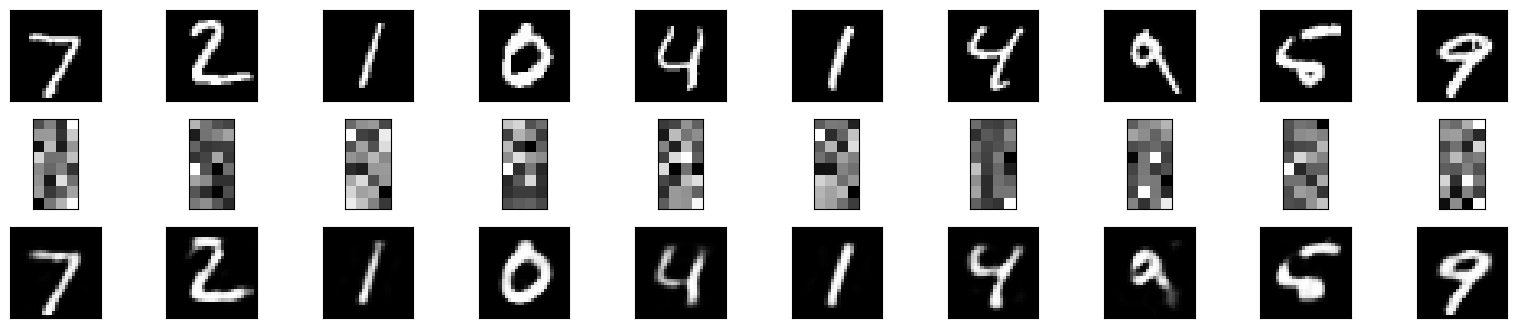

In [20]:
plt.figure(figsize=(40 , 4))
for i in range(10):
    ax = plt.subplot(3 , 20 , i + 1)
    plt.imshow(x_test[i].reshape(28 , 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(3 , 20 , i + 1 + 20)
    plt.imshow(encoded_image[i].reshape(8,4))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(3 , 20 , i + 1 + 2 * 20)
    plt.imshow(pred[i].reshape(28,28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

## 4. Add noise to data and see the result

In [21]:
import numpy as np

In [22]:
noise_amplitude = 0.5

x_train_noisy = x_train + noise_amplitude * np.random.normal(loc= 0.0 , scale= 1.0 , size= x_train.shape)
x_test_noisy = x_test + noise_amplitude * np.random.normal(loc= 0.0 , scale= 1.0 , size= x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0. , 1.)
x_test_noisy = np.clip(x_test_noisy, 0. , 1.)

In [24]:
x_train_noisy = x_train_noisy.reshape(len(x_train_noisy), 784)
x_test_noisy = x_test_noisy.reshape(len(x_test_noisy), 784)

In [25]:
autoencoder.fit(x_train_noisy , x_train,
                epochs= 30,
                batch_size= 256
                )

Epoch 1/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1758  
Epoch 2/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 957us/step - loss: 0.1437
Epoch 3/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 942us/step - loss: 0.1359
Epoch 4/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1319  
Epoch 5/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 926us/step - loss: 0.1296
Epoch 6/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1281
Epoch 7/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1270
Epoch 8/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1262
Epoch 9/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 930us/step - loss: 0.1256
Epoch 10/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1251
Epoch 11/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1248
Epoch 12/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1244
Epoch 13/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1242
Epoch 14/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1240
Epoch 15/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1

In [26]:
pred = autoencoder.predict(x_test_noisy)
encoded_image = encoder_model.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 593us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 517us/step


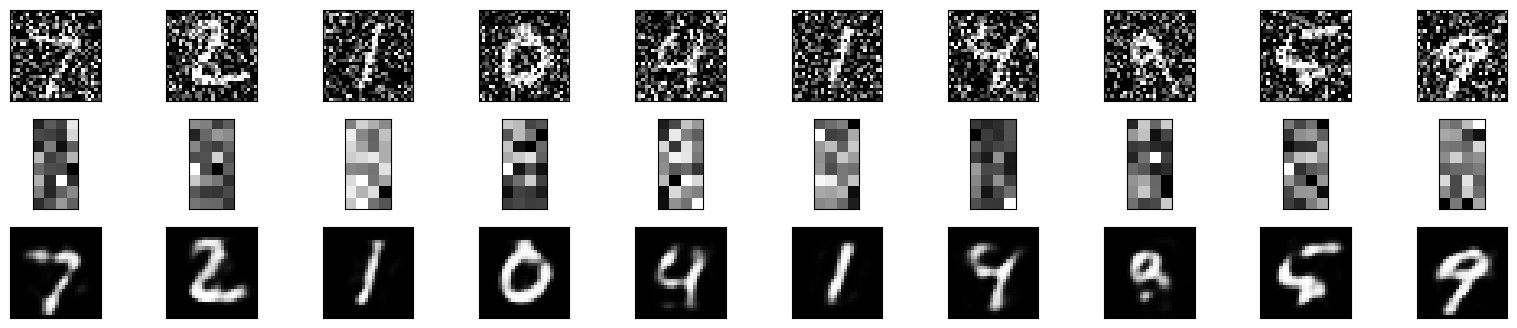

In [27]:
plt.figure(figsize=(40 , 4))
for i in range(10):
    ax = plt.subplot(3 , 20 , i + 1)
    plt.imshow(x_test_noisy[i].reshape(28 , 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(3 , 20 , i + 1 + 20)
    plt.imshow(encoded_image[i].reshape(8,4))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(3 , 20 , i + 1 + 2 * 20)
    plt.imshow(pred[i].reshape(28,28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()